# Modelos LSTM y similitud catch22 — Movimiento de Viajeros

## 0. Librerías

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

## 1. Carga y preparación de datos

In [6]:
def cargar_csv_robusto(path):
    intentos = [
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "latin-1", "sep": ","},
        {"encoding": "cp1252", "sep": ","},
    ]
    for params in intentos:
        try:
            df_test = pd.read_csv(path, **params, nrows=50)
            cols_ok = any("ñ" in c or "í" in c or "ó" in c for c in df_test.columns)
            texto_roto = any("M-CM-" in c or "AM-CM" in c for c in df_test.columns)
            if cols_ok and not texto_roto:
                return pd.read_csv(path, **params)
        except Exception:
            continue

    df_raw = pd.read_csv(path, encoding="latin-1", sep=",")

    def fix_text(x):
        if isinstance(x, str):
            try:
                return x.encode("latin-1").decode("utf-8")
            except (UnicodeDecodeError, UnicodeEncodeError):
                return x
        return x

    df_raw.columns = [fix_text(c) for c in df_raw.columns]
    for col in df_raw.select_dtypes(include="object").columns:
        df_raw[col] = df_raw[col].apply(fix_text)
    return df_raw


df = cargar_csv_robusto("../data/raw/Base_Migracion_2009-2026jun.csv")
df.columns = [c.strip() for c in df.columns]

rename_map = {
    "AM-CM-1o": "Año", "Mes cod": "Mes_cod", "VM-CM--a": "Vía",
    "PaM-CM--s": "País", "RegiM-CM-3n": "Región", "RegiM-CM-3n dos": "Región_dos",
    "AgrupaciM-CM-3n Residencia": "Agrupación_Residencia", "Tipo de Viajero": "Tipo_Viajero",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

df["Año"] = pd.to_numeric(df["Año"], errors="coerce").astype("Int64")
df["Mes_cod"] = pd.to_numeric(df["Mes_cod"], errors="coerce").astype("Int64")
df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes_cod"], day=1), errors="coerce")
df = df.dropna(subset=["Fecha", "Viajero"])

df.head()


,Año,Mes_cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo_Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


## 2. Series de tiempo a modelar

In [7]:
serie_total = df.groupby("Fecha")["Viajero"].sum().sort_index()

series_tipo = {
    f"Tipo_{tipo}": g.groupby("Fecha")["Viajero"].sum().sort_index()
    for tipo, g in df.groupby("Tipo_Viajero")
}

series_via = {
    f"Via_{via}": g.groupby("Fecha")["Viajero"].sum().sort_index()
    for via, g in df.groupby("Vía")
}

SERIES = {"Total": serie_total, **series_tipo, **series_via}
SERIES = {k: v.asfreq("MS").fillna(0.0) for k, v in SERIES.items() if len(v) >= 40}

{k: len(v) for k, v in SERIES.items()}


{'Total': 210,
 'Tipo_Cruceristas': 168,
 'Tipo_Excursionista': 210,
 'Tipo_Turista': 210,
 'Tipo_Viajero': 210,
 'Via_Aérea': 210,
 'Via_Marítima': 210,
 'Via_Terrestre': 210}

## 3. Utilidades: ventanas, split y escalado

In [8]:
WINDOW_GRID = [6, 12]

def create_sequences(values, window_size):
    X, y = [], []
    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size])
        y.append(values[i + window_size])
    return np.array(X), np.array(y)


def prepare_series(values, window_size, test_ratio=0.2):
    n = len(values)
    split_idx = int(n * (1 - test_ratio))

    scaler = MinMaxScaler()
    scaler.fit(values[:split_idx].reshape(-1, 1))
    scaled = scaler.transform(values.reshape(-1, 1)).flatten()

    X, y = create_sequences(scaled, window_size)
    target_idx = np.arange(window_size, n)
    train_mask = target_idx < split_idx

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[~train_mask], y[~train_mask]
    return X_train[..., None], y_train, X_test[..., None], y_test, scaler


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 4. LSTM

In [9]:
class LSTMSimple(nn.Module):
    def __init__(self, units=32, **kwargs):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=units, batch_first=True)
        self.fc = nn.Linear(units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class LSTMStacked(nn.Module):
    def __init__(self, units=32, dropout=0.2, **kwargs):
        super().__init__()
        units2 = max(units // 2, 4)
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=units, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=units, hidden_size=units2, batch_first=True)
        self.fc = nn.Linear(units2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop(out)
        out, _ = self.lstm2(out)
        return self.fc(out[:, -1, :])


PARAM_GRID = [
    {"window_size": 6, "units": 16, "dropout": 0.1, "lr": 1e-3},
    {"window_size": 12, "units": 32, "dropout": 0.2, "lr": 1e-3},
    {"window_size": 12, "units": 64, "dropout": 0.3, "lr": 5e-4},
]

ARCHITECTURES = {
    "LSTM_simple": LSTMSimple,
    "LSTM_stacked": LSTMStacked,
}


## 5. Tuneo de hiperparámetros y entrenamiento por serie

In [10]:
def train_torch_model(model, X_tr, y_tr, X_val, y_val, lr, epochs=100, batch_size=16, patience=8):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val).to(DEVICE)
    y_val_t = torch.tensor(y_val).to(DEVICE)

    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb).squeeze(-1)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze(-1)
            val_loss = loss_fn(val_pred, y_val_t).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val


def tune_series(name, series, epochs=100, batch_size=16, patience=8):
    values = series.values.astype("float32")
    trials = []

    for arch_name, model_cls in ARCHITECTURES.items():
        for params in PARAM_GRID:
            ws = params["window_size"]
            X_train, y_train, X_test, y_test, scaler = prepare_series(values, ws)
            if len(X_train) < 20 or len(X_test) < 4:
                continue

            val_split = int(len(X_train) * 0.85)
            X_tr, y_tr = X_train[:val_split], y_train[:val_split]
            X_val, y_val = X_train[val_split:], y_train[val_split:]

            torch.manual_seed(SEED)
            kwargs = dict(units=params["units"])
            if arch_name == "LSTM_stacked":
                kwargs["dropout"] = params["dropout"]
            model = model_cls(**kwargs)

            model, val_rmse_scaled = train_torch_model(
                model, X_tr, y_tr, X_val, y_val, lr=params["lr"],
                epochs=epochs, batch_size=batch_size, patience=patience,
            )
            val_rmse_scaled = float(np.sqrt(val_rmse_scaled))

            trials.append({
                "serie": name, "arch": arch_name, **params,
                "val_rmse_scaled": val_rmse_scaled,
                "model": model, "scaler": scaler,
                "X_test": X_test, "y_test": y_test,
            })

    if not trials:
        return None, None

    best = min(trials, key=lambda t: t["val_rmse_scaled"])
    trials_df = pd.DataFrame(trials).drop(columns=["model", "scaler", "X_test", "y_test"])
    return best, trials_df


all_trials = []
best_per_series = {}

for name, series in SERIES.items():
    best, trials_df = tune_series(name, series)
    if best is None:
        continue
    best_per_series[name] = best
    all_trials.append(trials_df)

trials_summary = pd.concat(all_trials, ignore_index=True)
trials_summary.sort_values(["serie", "val_rmse_scaled"]).head(20)


,serie,arch,window_size,units,dropout,lr,val_rmse_scaled
10,Tipo_Cruceristas,LSTM_stacked,12,32,0.2,0.0010,0.145965
6,Tipo_Cruceristas,LSTM_simple,6,16,0.1,0.0010,0.227334
7,Tipo_Cruceristas,LSTM_simple,12,32,0.2,0.0010,0.305415
11,Tipo_Cruceristas,LSTM_stacked,12,64,0.3,0.0005,0.307585
8,Tipo_Cruceristas,LSTM_simple,12,64,0.3,0.0005,0.313285
9,Tipo_Cruceristas,LSTM_stacked,6,16,0.1,0.0010,0.318974
13,Tipo_Excursionista,LSTM_simple,12,32,0.2,0.0010,0.112542
14,Tipo_Excursionista,LSTM_simple,12,64,0.3,0.0005,0.117876
16,Tipo_Excursionista,LSTM_stacked,12,32,0.2,0.0010,0.119303
17,Tipo_Excursionista,LSTM_stacked,12,64,0.3,0.0005,0.121509


## 6. Evaluación en test del mejor modelo por serie

In [11]:
def evaluate_best(best):
    model, scaler = best["model"], best["scaler"]
    X_test, y_test = best["X_test"], best["y_test"]

    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(torch.tensor(X_test).to(DEVICE)).squeeze(-1).cpu().numpy()

    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    return {
        "serie": best["serie"],
        "arch": best["arch"],
        "window_size": best["window_size"],
        "units": best["units"],
        "lr": best["lr"],
        "RMSE": rmse(y_test_orig, y_pred_orig),
        "MAE": mean_absolute_error(y_test_orig, y_pred_orig),
        "MAPE": mean_absolute_percentage_error(y_test_orig, y_pred_orig),
        "y_test": y_test_orig,
        "y_pred": y_pred_orig,
    }


eval_results = {name: evaluate_best(best) for name, best in best_per_series.items()}

metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_test", "y_pred")}
    for r in eval_results.values()
]).sort_values("RMSE")

metrics_df


,serie,arch,window_size,units,lr,RMSE,MAE,MAPE
6,Via_Marítima,LSTM_simple,12,32,0.0010,512.784129,498.285217,9.697707e-01
1,Tipo_Cruceristas,LSTM_stacked,12,32,0.0010,6534.541147,5536.878906,1.929982e+19
4,Tipo_Viajero,LSTM_simple,6,16,0.0010,12045.296509,6725.903809,2.802331e-01
2,Tipo_Excursionista,LSTM_simple,12,32,0.0010,13808.441476,10650.670898,1.696997e-01
5,Via_Aérea,LSTM_simple,6,16,0.0010,17731.844349,14657.973633,1.675423e-01
3,Tipo_Turista,LSTM_simple,12,64,0.0005,38866.997003,31052.535156,1.632607e-01
7,Via_Terrestre,LSTM_simple,12,64,0.0005,44248.107756,34444.429688,1.797285e-01
0,Total,LSTM_simple,12,64,0.0005,57448.982028,42604.171875,1.506934e-01


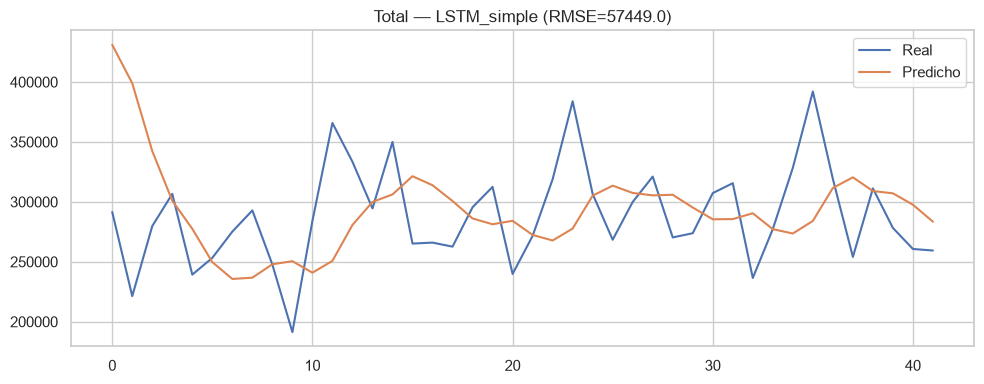

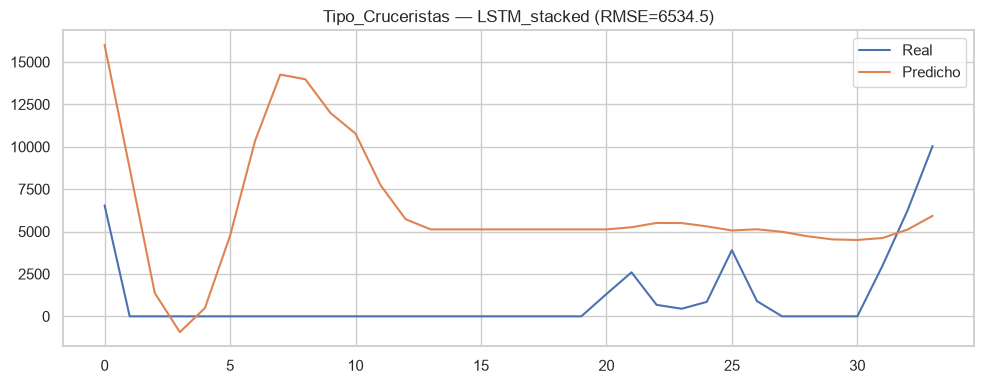

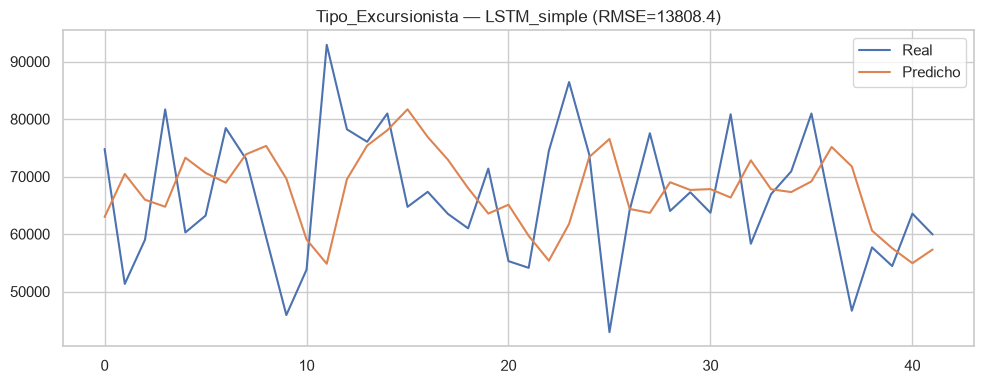

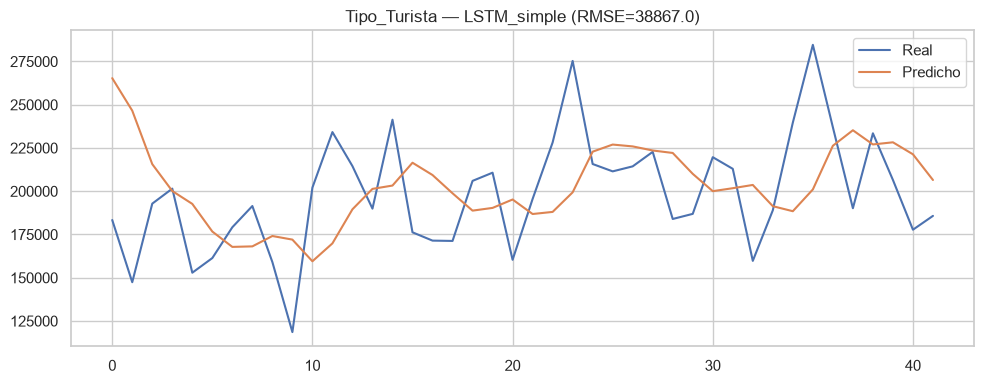

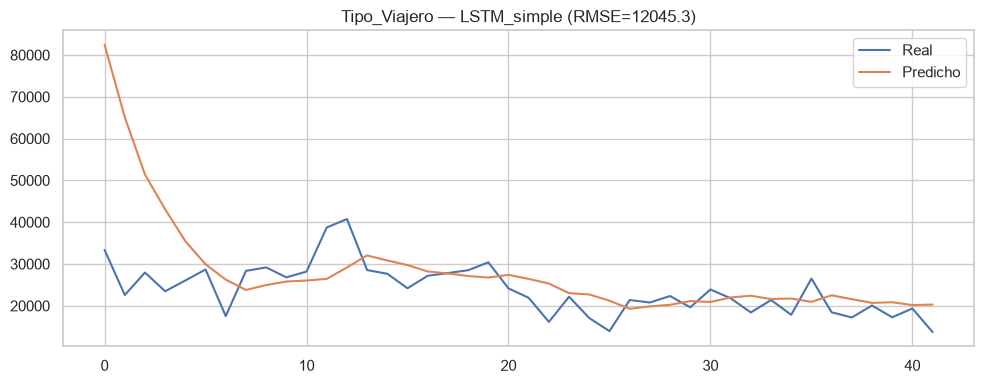

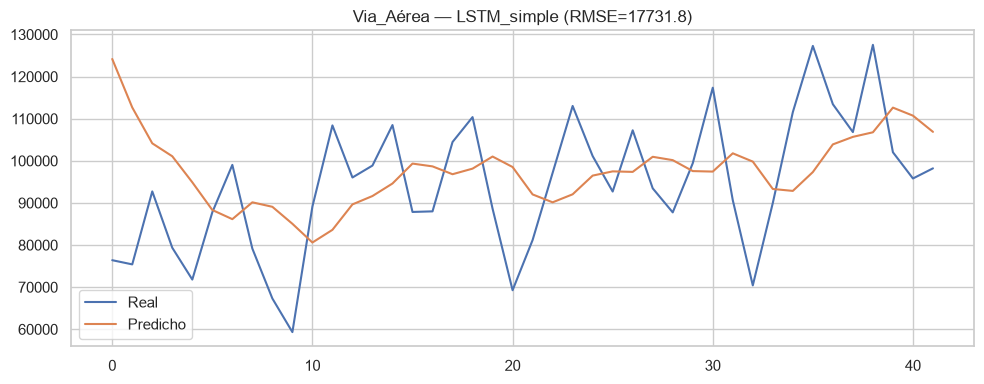

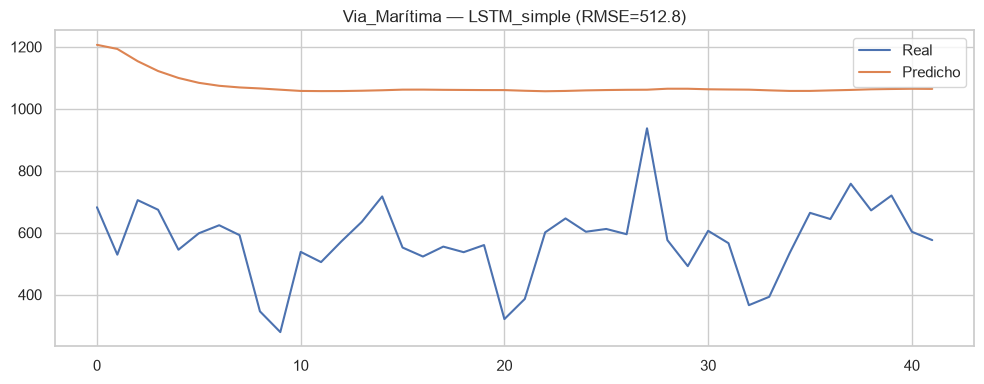

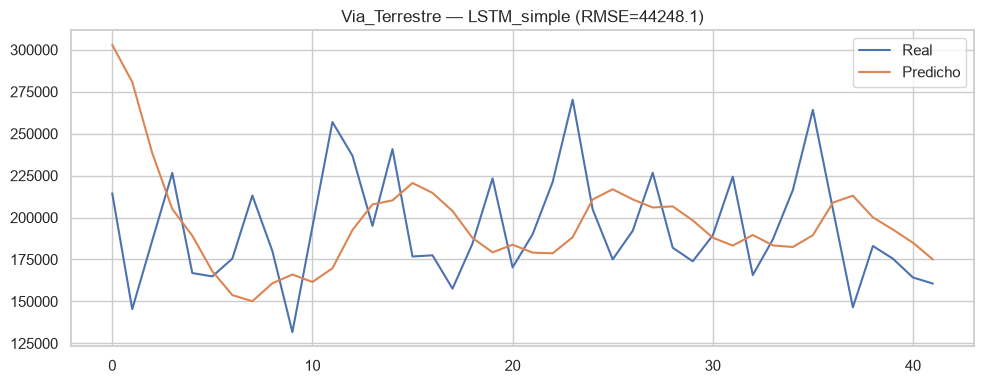

In [12]:
for name, r in eval_results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(r["y_test"], label="Real")
    plt.plot(r["y_pred"], label="Predicho")
    plt.title(f"{name} — {r['arch']} (RMSE={r['RMSE']:.1f})")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Similitud entre series con catch22

Utilice todas las series temporales construidas durante el laboratorio anterior (serie total y las series correspondientes a las categorías seleccionadas).

2.1. Explique brevemente cuál es la idea detrás de catch22 según lo que recuerda de la conferencia y porqué es importante.

- catch22 es un conjunto de 22 características de series temporales que capturan diferentes aspectos de la dinámica temporal, como la autocorrelación, la entropía, la complejidad y la periodicidad. Estas características son útiles para comparar y clasificar series temporales, ya que permiten identificar patrones y similitudes entre ellas. La importancia de catch22 radica en su capacidad para resumir información relevante de las series temporales en un conjunto compacto de características, facilitando el análisis y la interpretación de los datos.

In [13]:
!pip install pycatch22 -q



[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


2.2. Extraiga las 22 características de catch22 para cada serie temporal.

In [14]:
import pycatch22

def catch22_features(series_dict):
    feat_rows = {}
    feat_names = None
    for name, s in series_dict.items():
        vals = s.values.astype(float).tolist()
        res = pycatch22.catch22_all(vals)
        if feat_names is None:
            feat_names = res["names"]
        feat_rows[name] = res["values"]
    return pd.DataFrame(feat_rows, index=feat_names).T


feat_df = catch22_features(SERIES)
feat_df.head()


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.188540,-0.580353,8.578892,10.0,0.453530,-0.126601,0.913876,30.0,0.013774,11.0,...,0.055556,0.219048,0.323810,0.829129,6.0,1.846797,0.761905,0.857143,0.147262,0.627355
Tipo_Cruceristas,-0.529704,-0.745388,1.928428,6.0,0.111917,-0.073415,0.820359,9.0,0.006122,11.0,...,0.200000,0.297619,0.363095,0.711107,5.0,2.022264,0.146341,0.731707,0.515418,0.939798
Tipo_Excursionista,-0.351261,-0.579081,10.624822,15.0,0.510622,-0.042198,0.904306,30.0,0.005510,52.0,...,0.052632,0.266667,0.319048,0.853298,4.0,1.793196,0.761905,0.857143,0.098175,0.554374
Tipo_Turista,-0.036878,0.224708,8.721277,2.0,0.266628,-0.070405,0.971292,30.0,0.013774,3.0,...,0.055556,0.152381,0.323810,0.794164,6.0,1.868443,0.857143,0.857143,0.147262,0.670087
Tipo_Viajero,-0.344914,-0.606070,7.272866,11.0,0.305492,-0.450194,0.751196,18.0,0.041667,35.0,...,0.023810,0.557143,-0.452381,0.804758,5.0,1.825859,0.857143,0.571429,0.171806,0.667356


2.3. Construya una matriz donde:
• Cada fila represente una serie temporal.
• Cada columna corresponda a una característica de catch22.

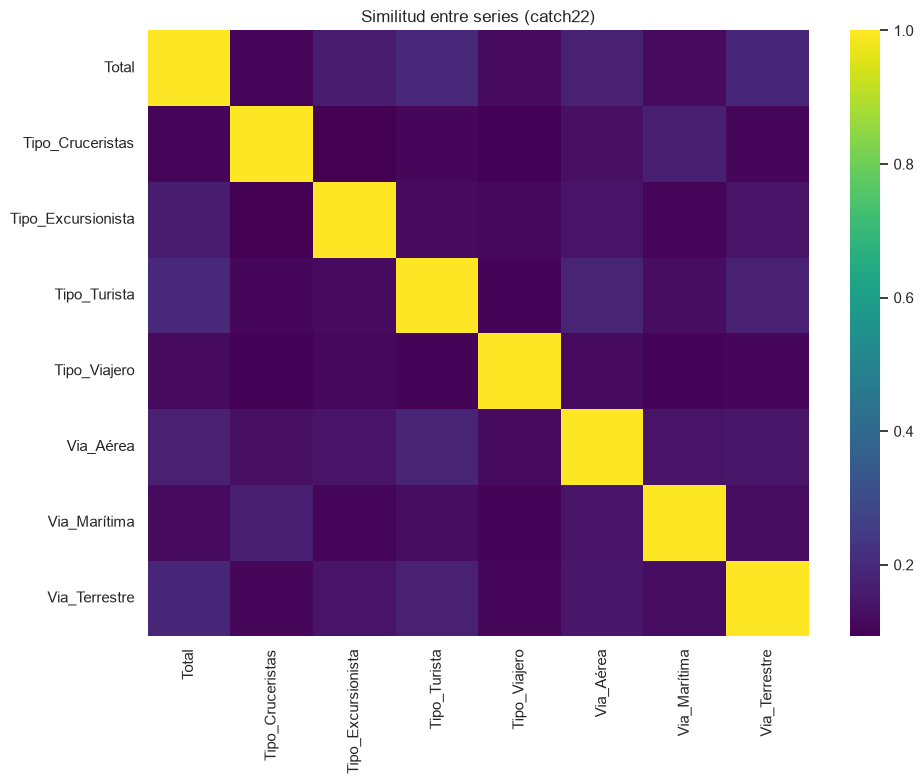

In [15]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

feat_scaled = StandardScaler().fit_transform(feat_df.values)
dist_matrix = squareform(pdist(feat_scaled, metric="euclidean"))
dist_df = pd.DataFrame(dist_matrix, index=feat_df.index, columns=feat_df.index)

sim_df = 1 / (1 + dist_df)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_df, cmap="viridis", annot=False)
plt.title("Similitud entre series (catch22)")
plt.tight_layout()
plt.show()


Explicacion de la matriz de características obtenida, incluyendo la interpretación de las características más relevantes y cómo estas pueden ayudar a entender la dinámica de las series temporales analizadas. 

- La matriz de características obtenida muestra las 22 características de catch22 para cada una de las series temporales analizadas. Cada fila representa una serie temporal y cada columna corresponde a una característica específica. Esta representación permite visualizar y analizar las similitudes y diferencias entre las series temporales en términos de sus características.

Explicación: La matriz resultante tendrá dimensiones (n_series, 22), donde n_series es el número total de series temporales analizadas. Cada elemento de la matriz representará el valor de una característica específica de catch22 para una serie temporal determinada.

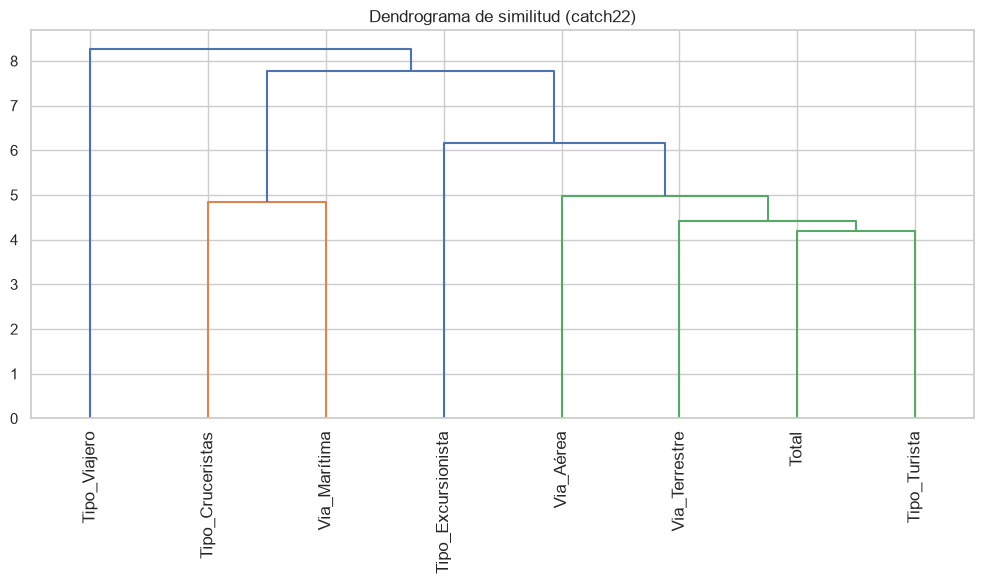

In [16]:
link = linkage(pdist(feat_scaled, metric="euclidean"), method="average")

plt.figure(figsize=(10, 6))
dendrogram(link, labels=feat_df.index.tolist(), leaf_rotation=90)
plt.title("Dendrograma de similitud (catch22)")
plt.tight_layout()
plt.show()


Explicacion del dendrograma de similitud entre series, incluyendo cómo se interpretan los clusters y qué información se puede extraer sobre la relación entre las series temporales analizadas.

- El dendrograma de similitud entre series se construye a partir de la matriz de características obtenida con catch22. Cada nodo del dendrograma representa una serie temporal, y las ramas indican la similitud entre ellas. Las series que se agrupan en el mismo cluster comparten características similares, lo que sugiere que tienen patrones de comportamiento similares en términos de tendencia, estacionalidad y ruido.

2.4. Estandarice las características antes de realizar cualquier análisis comparativo.

In [17]:

scaler_feat = StandardScaler()
feat_scaled = scaler_feat.fit_transform(feat_df)

feat_scaled_df = pd.DataFrame(
    feat_scaled,
    index=feat_df.index,
    columns=feat_df.columns
)

feat_scaled_df.head()

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,2.080663,-0.306584,0.576535,0.517533,0.881323,0.096007,0.513193,0.654504,0.058951,-0.379412,...,-0.518809,-0.192486,0.309782,0.824391,1.133893,-0.268569,0.129809,0.564226,-0.546586,-0.657333
Tipo_Cruceristas,-0.931030,-0.812584,-1.729721,-0.456647,-1.284120,0.525817,-0.424823,-1.544630,-0.621406,-0.379412,...,1.700853,0.365935,0.458207,-1.738670,-0.377964,1.823789,-2.594886,-0.737487,1.715150,1.844470
Tipo_Excursionista,-0.182795,-0.302687,1.286025,1.735258,1.243228,0.778096,0.417207,0.654504,-0.675835,2.160326,...,-0.563742,0.145951,0.291791,1.349254,-1.889822,-0.907740,0.129809,0.564226,-0.848151,-1.241707
Tipo_Turista,1.135456,2.161732,0.625912,-1.430827,-0.303426,0.550146,1.089106,0.654504,0.058951,-0.874971,...,-0.518809,-0.666299,0.309782,0.065070,1.133893,-0.010447,0.551365,0.564226,-0.546586,-0.315168
Tipo_Viajero,-0.156180,-0.385434,0.123630,0.761078,-0.057073,-2.519057,-1.118563,-0.602144,2.538855,1.107264,...,-1.006647,2.210419,-2.622745,0.295134,-0.377964,-0.518242,0.551365,-2.400787,-0.395804,-0.337033


2.5. Utilizando la matriz obtenida, realice los siguientes análisis:

• Análisis de Componentes Principales (PCA).

• Clustering

• Mapa de calor (Heatmap) de las características.

• Matriz de correlaciones entre características.

• Mapa de distancias entre series.

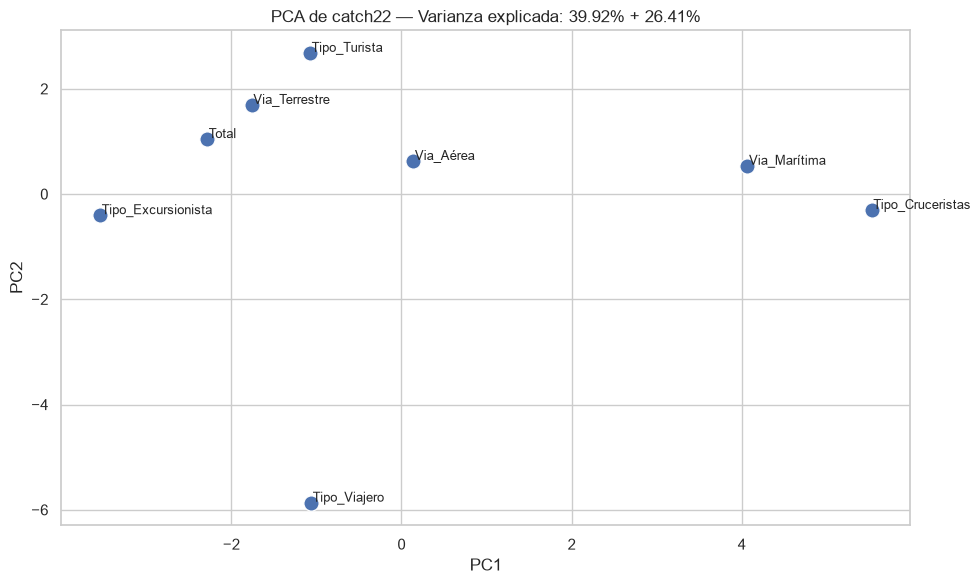

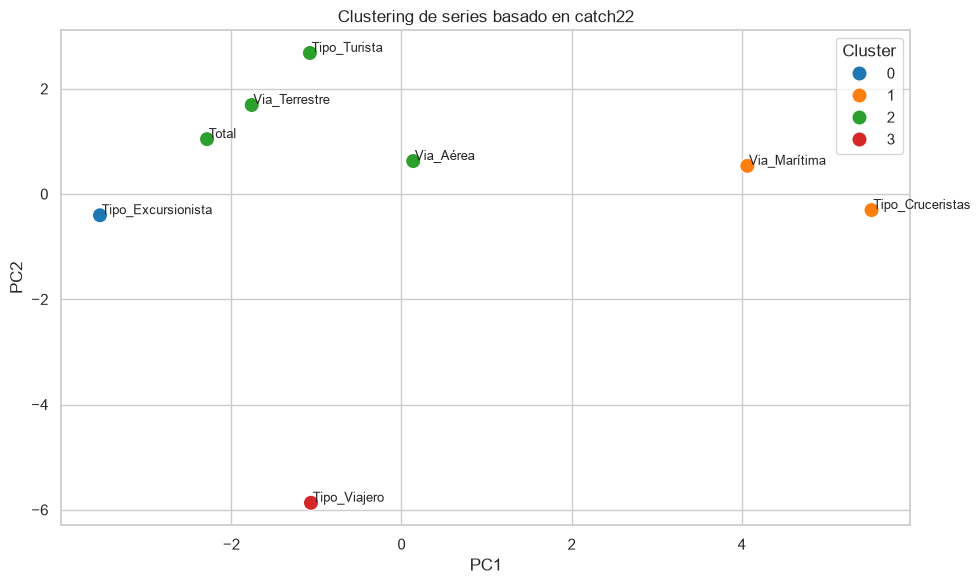

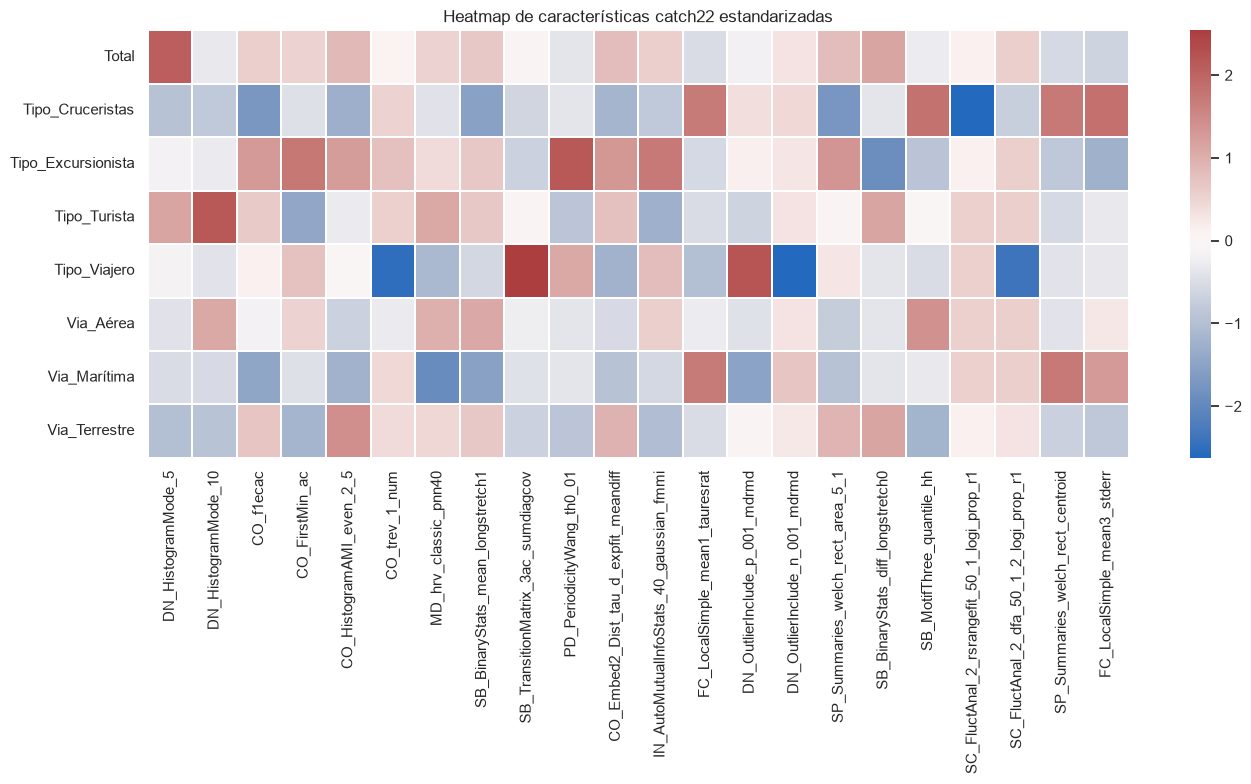

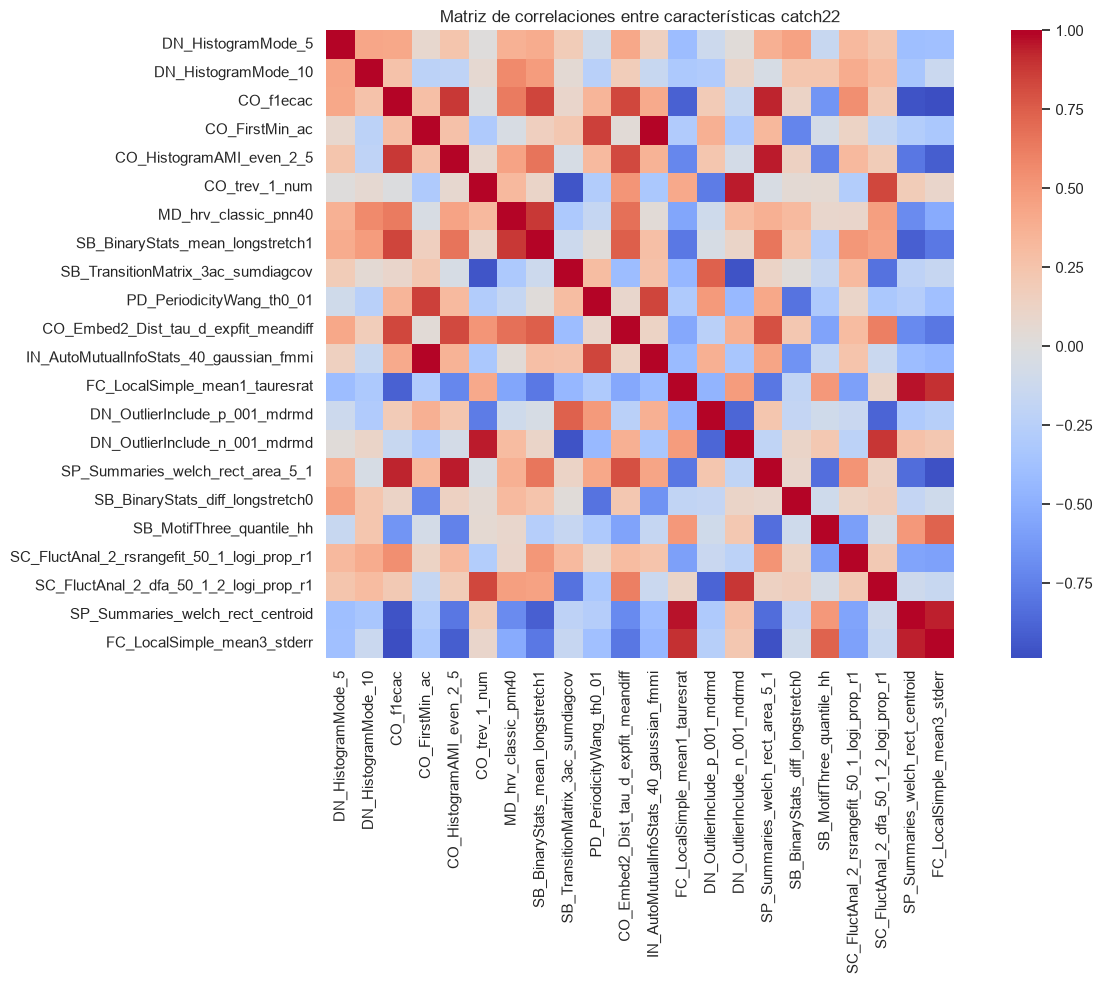

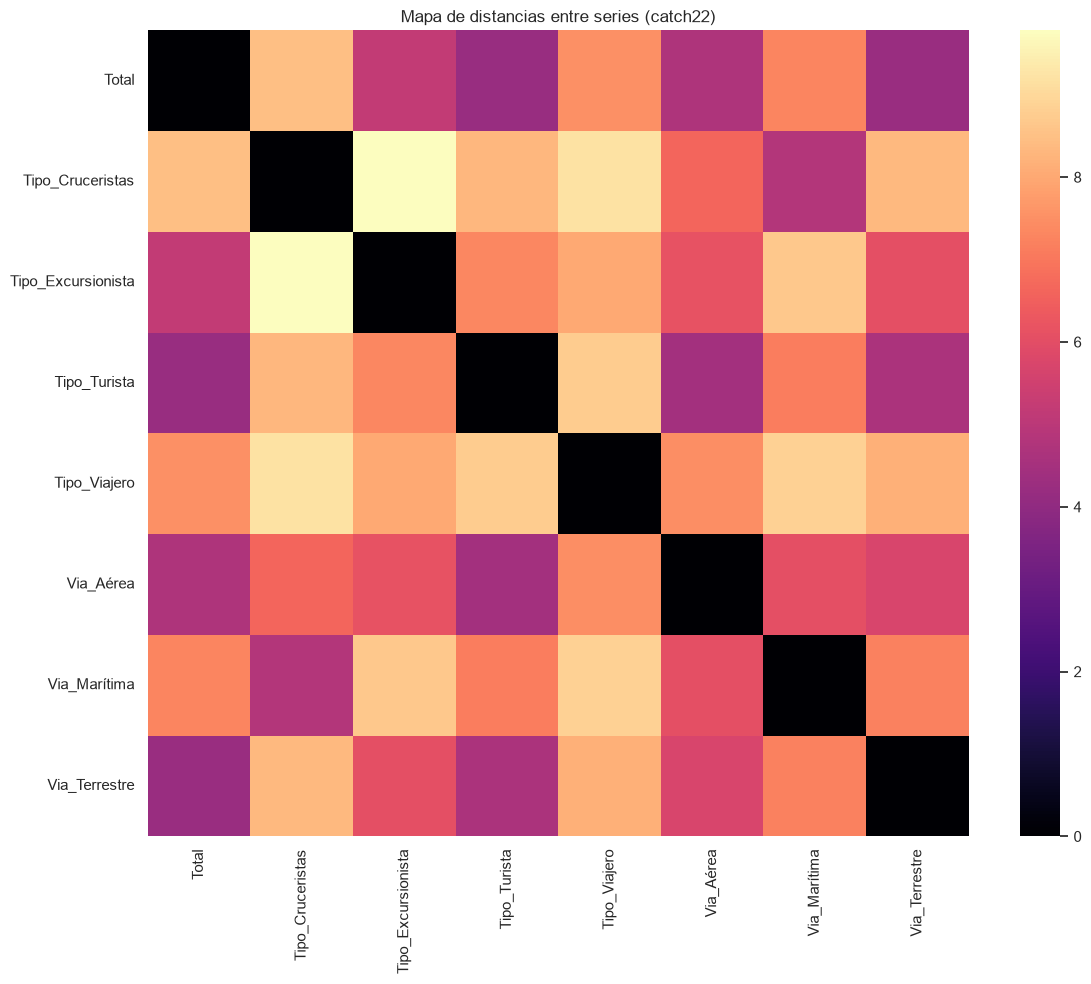

,serie,cluster
2,Tipo_Excursionista,0
1,Tipo_Cruceristas,1
6,Via_Marítima,1
3,Tipo_Turista,2
0,Total,2
5,Via_Aérea,2
7,Via_Terrestre,2
4,Tipo_Viajero,3


In [18]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- PCA ---
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(feat_scaled_df.values)

pca_df = pd.DataFrame(
    pca_coords,
    index=feat_scaled_df.index,
    columns=["PC1", "PC2"]
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=120)

for name, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, name, fontsize=9)

plt.title(
    f"PCA de catch22 — Varianza explicada: "
    f"{pca.explained_variance_ratio_[0]:.2%} + {pca.explained_variance_ratio_[1]:.2%}"
)
plt.tight_layout()
plt.show()

# --- Clustering ---
n_clusters = min(4, len(feat_scaled_df))
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(feat_scaled_df.values)

cluster_df = pca_df.copy()
cluster_df["cluster"] = cluster_labels.astype(int)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=120)

for name, row in cluster_df.iterrows():
    plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, name, fontsize=9)

plt.title("Clustering de series basado en catch22")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# --- Heatmap de características estandarizadas ---
plt.figure(figsize=(14, 8))
sns.heatmap(feat_scaled_df, cmap="vlag", center=0, linewidths=0.3)
plt.title("Heatmap de características catch22 estandarizadas")
plt.tight_layout()
plt.show()

# --- Matriz de correlaciones entre características ---
corr_df = feat_scaled_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlaciones entre características catch22")
plt.tight_layout()
plt.show()

# --- Mapa de distancias entre series ---
dist_matrix = squareform(pdist(feat_scaled_df.values, metric="euclidean"))
dist_df = pd.DataFrame(dist_matrix, index=feat_scaled_df.index, columns=feat_scaled_df.index)

plt.figure(figsize=(12, 10))
sns.heatmap(dist_df, cmap="magma", annot=False)
plt.title("Mapa de distancias entre series (catch22)")
plt.tight_layout()
plt.show()

# --- Resumen de clusters ---
clusters_result = pd.DataFrame(
    {"serie": feat_scaled_df.index, "cluster": cluster_labels}
).sort_values(["cluster", "serie"])

clusters_result

2.6. Análisis e interpretación. Con base en los resultados obtenidos responda las siguientes preguntas.



2.7. ¿Cuáles series presentan comportamientos más similares? Justifique utilizando la representación obtenida mediante PCA, clustering u otra técnica utilizada.

Pares de series más similares:


,serie_1,serie_2,distancia
0,Total,Tipo_Turista,4.189170
1,Total,Via_Terrestre,4.208534
2,Tipo_Turista,Via_Aérea,4.461410
3,Tipo_Turista,Via_Terrestre,4.629161
4,Total,Via_Aérea,4.735808
5,Tipo_Cruceristas,Via_Marítima,4.841255
6,Total,Tipo_Excursionista,5.165396
7,Via_Aérea,Via_Terrestre,5.705036
8,Via_Aérea,Via_Marítima,6.055683
9,Tipo_Excursionista,Via_Terrestre,6.063677



Series agrupadas por cluster:
Cluster 0: ['Tipo_Excursionista']
Cluster 1: ['Tipo_Cruceristas', 'Via_Marítima']
Cluster 2: ['Tipo_Turista', 'Total', 'Via_Aérea', 'Via_Terrestre']
Cluster 3: ['Tipo_Viajero']

La pareja más similar es Total y Tipo_Turista, con distancia 4.1892.


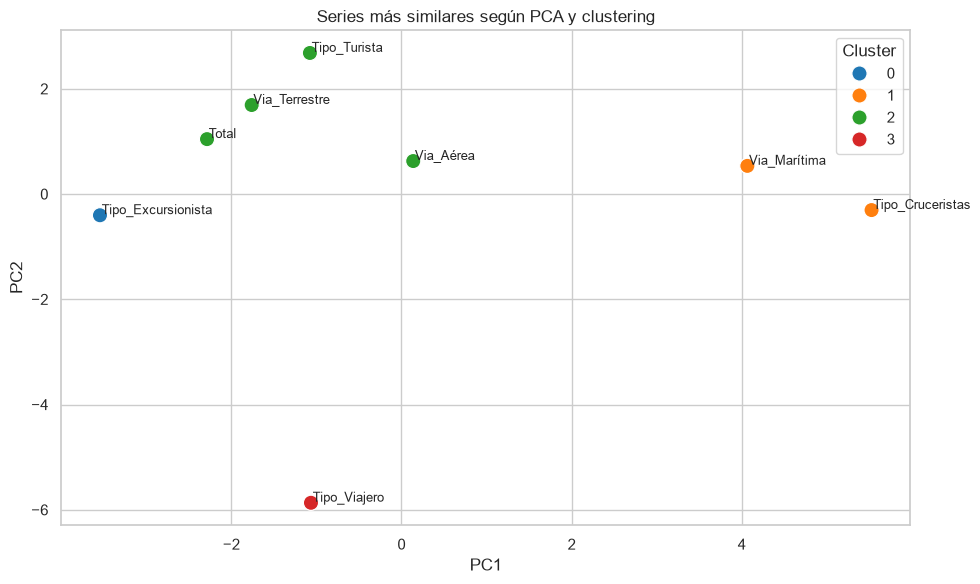

In [19]:
from itertools import combinations

# Series más similares según distancia euclídea sobre catch22
pairs = []
for a, b in combinations(dist_df.index, 2):
    pairs.append((a, b, dist_df.loc[a, b]))

pairs_df = pd.DataFrame(pairs, columns=["serie_1", "serie_2", "distancia"])
pairs_df = pairs_df.sort_values("distancia").reset_index(drop=True)

print("Pares de series más similares:")
display(pairs_df.head(10))

print("\nSeries agrupadas por cluster:")
for c in sorted(clusters_result["cluster"].unique()):
    series_cluster = clusters_result.loc[clusters_result["cluster"] == c, "serie"].tolist()
    print(f"Cluster {c}: {series_cluster}")

# Resumen breve de similitud
if len(pairs_df) > 0:
    most_similar = pairs_df.iloc[0]
    print(
        f"\nLa pareja más similar es {most_similar['serie_1']} y {most_similar['serie_2']}, "
        f"con distancia {most_similar['distancia']:.4f}."
    )

# Visualización opcional del PCA con etiquetas de cluster
plt.figure(figsize=(10, 6))
plot_df = pca_df.copy()
plot_df["cluster"] = cluster_labels.astype(int)

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=120)

for name, row in plot_df.iterrows():
    plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, name, fontsize=9)

plt.title("Series más similares según PCA y clustering")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

2.8. ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

2.9. ¿Existen grupos naturales de series? En caso afirmativo, describa qué tienen en común.

In [20]:
from sklearn.feature_selection import f_classif

# Unir series y cluster
analysis_df = feat_scaled_df.copy()
analysis_df["cluster"] = cluster_labels

# 2.8. Características más importantes para diferenciar las series
X = feat_scaled_df.values
y = cluster_labels

f_scores, p_values = f_classif(X, y)

importance_df = pd.DataFrame({
    "feature": feat_scaled_df.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print("Top características que más diferencian las series:")
display(importance_df.head(10))

# Perfil promedio por cluster
cluster_profile = analysis_df.groupby("cluster").mean(numeric_only=True)

print("Perfil promedio de características por cluster:")
display(cluster_profile)

# 2.9. Grupos naturales de series
clusters_result = pd.DataFrame({
    "serie": feat_scaled_df.index,
    "cluster": cluster_labels
}).sort_values(["cluster", "serie"])

print("Series agrupadas por cluster:")
for c in sorted(clusters_result["cluster"].unique()):
    series_cluster = clusters_result.loc[clusters_result["cluster"] == c, "serie"].tolist()
    print(f"Cluster {c}: {series_cluster}")

# Resumen de características más distintivas por cluster
for c in cluster_profile.index:
    top_feats = cluster_profile.loc[c].abs().sort_values(ascending=False).head(5)
    print(f"\nCluster {c} — características más marcadas:")
    display(top_feats.to_frame(name="valor_abs"))

Top características que más diferencian las series:


,feature,f_score,p_value
14,DN_OutlierInclude_n_001_mdrmd,373.021299,0.000024
12,FC_LocalSimple_mean1_tauresrat,237.709861,0.000058
20,SP_Summaries_welch_rect_centroid,233.250000,0.000060
7,SB_BinaryStats_mean_longstretch1,79.722222,0.000505
9,PD_PeriodicityWang_th0_01,42.101563,0.001749
8,SB_TransitionMatrix_3ac_sumdiagcov,26.507943,0.004231
5,CO_trev_1_num,23.827045,0.005172
2,CO_f1ecac,18.318632,0.008433
21,FC_LocalSimple_mean3_stderr,10.869824,0.021551
19,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,10.611201,0.022475


Perfil promedio de características por cluster:


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.182795,-0.302687,1.286025,1.735258,1.243228,0.778096,0.417207,0.654504,-0.675835,2.160326,...,-0.563742,0.145951,0.291791,1.349254,-1.889822,-0.907740,0.129809,0.564226,-0.848151,-1.241707
1,-0.726981,-0.669855,-1.583632,-0.456647,-1.249145,0.490006,-1.179632,-1.544630,-0.523315,-0.379412,...,1.700853,-0.573228,0.572900,-1.350693,-0.377964,0.755746,-1.021761,-0.086630,1.715150,1.561209
2,0.448234,0.506958,0.439402,-0.395761,0.328034,0.190237,0.765155,0.759225,-0.204097,-0.627191,...,-0.457829,-0.302478,0.296289,0.264250,0.755929,-0.021378,0.340587,0.502455,-0.546586,-0.385920
3,-0.156180,-0.385434,0.123630,0.761078,-0.057073,-2.519057,-1.118563,-0.602144,2.538855,1.107264,...,-1.006647,2.210419,-2.622745,0.295134,-0.377964,-0.518242,0.551365,-2.400787,-0.395804,-0.337033


Series agrupadas por cluster:
Cluster 0: ['Tipo_Excursionista']
Cluster 1: ['Tipo_Cruceristas', 'Via_Marítima']
Cluster 2: ['Tipo_Turista', 'Total', 'Via_Aérea', 'Via_Terrestre']
Cluster 3: ['Tipo_Viajero']

Cluster 0 — características más marcadas:


...

,valor_abs
SP_Summaries_welch_rect_centroid,1.715150
FC_LocalSimple_mean1_tauresrat,1.700853
CO_f1ecac,1.583632
FC_LocalSimple_mean3_stderr,1.561209
SB_BinaryStats_mean_longstretch1,1.544630



Cluster 2 — características más marcadas:


,valor_abs
MD_hrv_classic_pnn40,0.765155
SB_BinaryStats_mean_longstretch1,0.759225
SB_BinaryStats_diff_longstretch0,0.755929
PD_PeriodicityWang_th0_01,0.627191
SP_Summaries_welch_rect_centroid,0.546586



Cluster 3 — características más marcadas:


,valor_abs
DN_OutlierInclude_n_001_mdrmd,2.622745
SB_TransitionMatrix_3ac_sumdiagcov,2.538855
CO_trev_1_num,2.519057
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,2.400787
DN_OutlierInclude_p_001_mdrmd,2.210419


2.10. ¿Las series pertenecientes a una misma categoría (países, regiones, vías de ingreso, fronteras o tipo de viajero) tienden a agruparse o presentan comportamientos significativamente diferentes?

Conteo categoría vs cluster:


cluster,0,1,2,3
categoria,,,,
Tipo de viajero,1,1,1,1
Total,0,0,1,0
Vía de ingreso,0,1,2,0


Proporción por categoría:


cluster,0,1,2,3
categoria,,,,
Tipo de viajero,0.25,0.250,0.250,0.25
Total,0.00,0.000,1.000,0.00
Vía de ingreso,0.00,0.333,0.667,0.00


Resumen de agrupación:


,categoria,cluster_dominante,proporcion_dominante,n_series
1,Total,2,1.000000,1
2,Vía de ingreso,2,0.666667,3
0,Tipo de viajero,0,0.250000,4


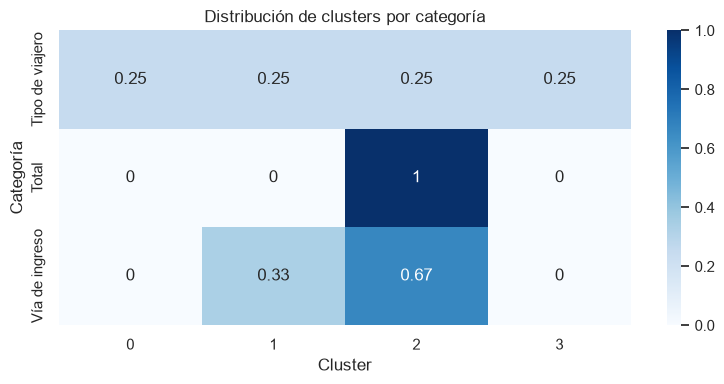

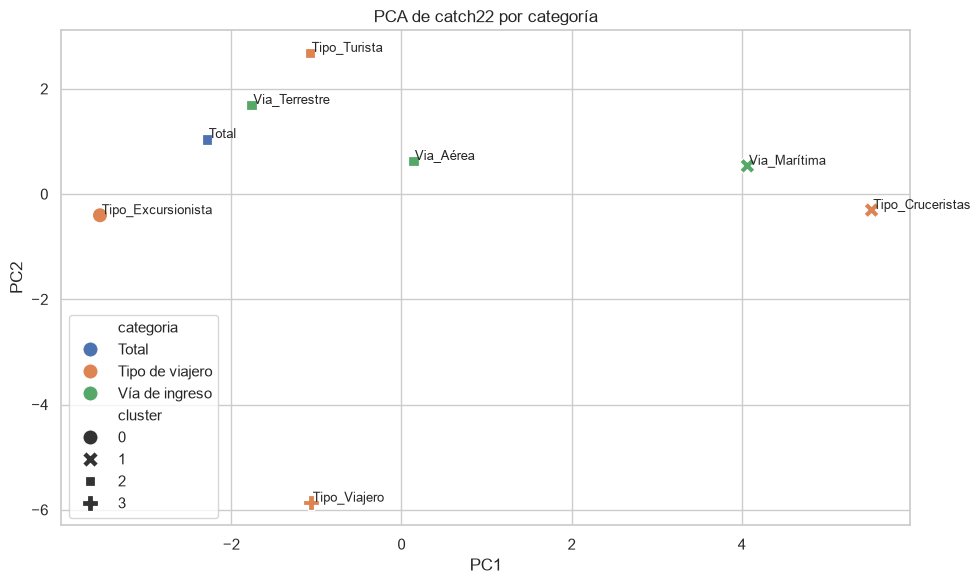

Interpretación breve:
- Total: cluster dominante 2 (100.0% de las series de esa categoría).
- Vía de ingreso: cluster dominante 2 (66.7% de las series de esa categoría).
- Tipo de viajero: cluster dominante 0 (25.0% de las series de esa categoría).


In [22]:
def infer_category(name):
    if name == "Total":
        return "Total"
    if name.startswith("Tipo_"):
        return "Tipo de viajero"
    if name.startswith("Via_"):
        return "Vía de ingreso"
    return "Otra"

analysis_df = feat_scaled_df.copy()
analysis_df["cluster"] = cluster_labels
analysis_df["categoria"] = [infer_category(name) for name in analysis_df.index]
analysis_df = analysis_df.join(pca_df)

# Resumen de agrupación por categoría
tabla_cat_cluster = pd.crosstab(analysis_df["categoria"], analysis_df["cluster"])
tabla_cat_cluster_prop = tabla_cat_cluster.div(tabla_cat_cluster.sum(axis=1), axis=0)

print("Conteo categoría vs cluster:")
display(tabla_cat_cluster)

print("Proporción por categoría:")
display(tabla_cat_cluster_prop.round(3))

# Medida simple de concentración: cluster dominante por categoría
resumen = []
for cat, row in tabla_cat_cluster_prop.iterrows():
    dom_cluster = row.idxmax()
    dom_share = row.max()
    resumen.append({
        "categoria": cat,
        "cluster_dominante": int(dom_cluster),
        "proporcion_dominante": float(dom_share),
        "n_series": int(tabla_cat_cluster.loc[cat].sum())
    })

resumen_df = pd.DataFrame(resumen).sort_values("proporcion_dominante", ascending=False)
print("Resumen de agrupación:")
display(resumen_df)

# Mapa de calor categoría vs cluster
plt.figure(figsize=(8, 4))
sns.heatmap(tabla_cat_cluster_prop, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Distribución de clusters por categoría")
plt.xlabel("Cluster")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

# PCA coloreado por categoría
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analysis_df.reset_index().rename(columns={"index": "serie"}),
    x="PC1", y="PC2",
    hue="categoria",
    style="cluster",
    s=120
)
for name, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, name, fontsize=9)
plt.title("PCA de catch22 por categoría")
plt.tight_layout()
plt.show()

print("Interpretación breve:")
for _, row in resumen_df.iterrows():
    print(
        f"- {row['categoria']}: cluster dominante {row['cluster_dominante']} "
        f"({row['proporcion_dominante']:.1%} de las series de esa categoría)."
    )

2.11. Identifique las series que presentan el comportamiento más atípico respecto al resto y explique, utilizando los resultados obtenidos anteriormente, qué podría justificar dicho comportamiento.

Series más atípicas según catch22:


,serie,distancia_media,distancia_vecino_cercano,z_media,z_vecino,score_atipicidad
0,Tipo_Viajero,7.234701,7.459433,1.619976,2.492746,4.112722
1,Tipo_Cruceristas,6.941108,4.841255,1.222992,-0.076744,1.146248
2,Tipo_Excursionista,6.390326,5.165396,0.478250,0.241369,0.719619
3,Via_Marítima,6.255326,4.841255,0.295709,-0.076744,0.218965
4,Tipo_Turista,5.592257,4.189170,-0.600863,-0.716702,-1.317565
5,Via_Terrestre,5.541066,4.208534,-0.670080,-0.697698,-1.367778
6,Via_Aérea,5.146109,4.461410,-1.204123,-0.449525,-1.653648
7,Total,5.192156,4.189170,-1.141861,-0.716702,-1.858563


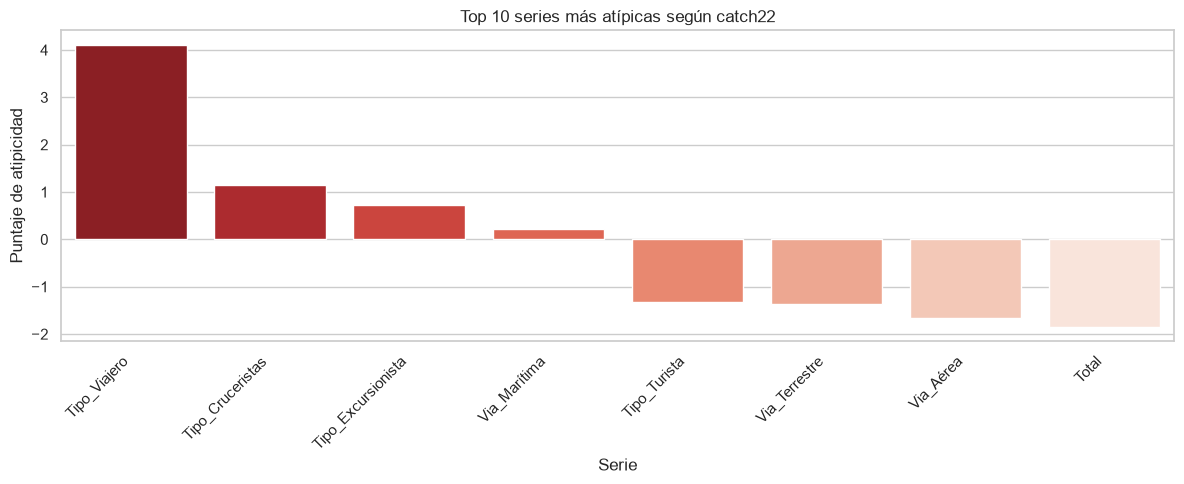

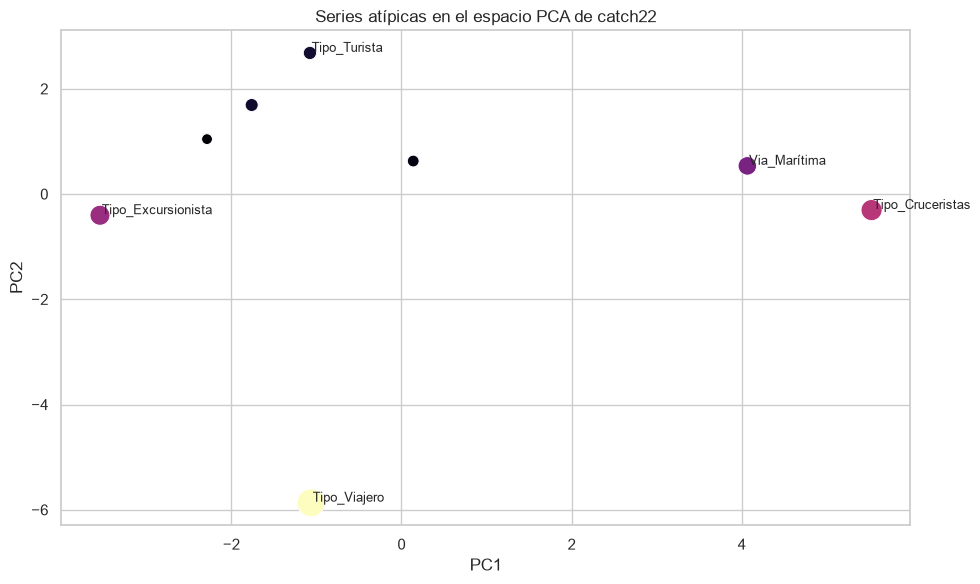


Interpretación breve:
- Las series más atípicas son: Tipo_Viajero, Tipo_Cruceristas, Tipo_Excursionista.
- Esto suele indicar perfiles temporales con dinámica distinta, por ejemplo mayor ruptura estructural, cambios bruscos o patrones de estacionalidad diferentes.


In [23]:
# 2.11. Series más atípicas respecto al resto

# Distancia promedio a las demás series en el espacio catch22
mean_dist = dist_df.mean(axis=1)

# Distancia al vecino más cercano
nearest_dist = dist_df.replace(0, np.nan).min(axis=1)

# Puntaje combinado de atipicidad
outlier_df = pd.DataFrame({
    "serie": dist_df.index,
    "distancia_media": mean_dist.values,
    "distancia_vecino_cercano": nearest_dist.values,
})

outlier_df["z_media"] = (outlier_df["distancia_media"] - outlier_df["distancia_media"].mean()) / outlier_df["distancia_media"].std(ddof=0)
outlier_df["z_vecino"] = (outlier_df["distancia_vecino_cercano"] - outlier_df["distancia_vecino_cercano"].mean()) / outlier_df["distancia_vecino_cercano"].std(ddof=0)
outlier_df["score_atipicidad"] = outlier_df["z_media"] + outlier_df["z_vecino"]

outlier_df = outlier_df.sort_values("score_atipicidad", ascending=False).reset_index(drop=True)

print("Series más atípicas según catch22:")
display(outlier_df.head(10))

# Visualización
plt.figure(figsize=(12, 5))
sns.barplot(data=outlier_df.head(10), x="serie", y="score_atipicidad", palette="Reds_r")
plt.title("Top 10 series más atípicas según catch22")
plt.xlabel("Serie")
plt.ylabel("Puntaje de atipicidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Resaltar atípicas en PCA, si ya existe pca_df
if "pca_df" in globals():
    pca_out = pca_df.copy()
    pca_out["score_atipicidad"] = outlier_df.set_index("serie").loc[pca_out.index, "score_atipicidad"]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=pca_out.reset_index().rename(columns={"index": "serie"}),
        x="PC1", y="PC2",
        size="score_atipicidad",
        sizes=(60, 400),
        hue="score_atipicidad",
        palette="magma",
        legend=False
    )

    for name, row in pca_out.iterrows():
        if name in outlier_df.head(5)["serie"].tolist():
            plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, name, fontsize=9)

    plt.title("Series atípicas en el espacio PCA de catch22")
    plt.tight_layout()
    plt.show()

# Resumen textual
top_outliers = outlier_df.head(3)["serie"].tolist()
print("\nInterpretación breve:")
print(f"- Las series más atípicas son: {', '.join(top_outliers)}.")
print("- Esto suele indicar perfiles temporales con dinámica distinta, por ejemplo mayor ruptura estructural, cambios bruscos o patrones de estacionalidad diferentes.")

2.12. Compare los resultados obtenidos mediante catch22 con el análisis exploratorio realizado anteriormente.

o ¿Los agrupamientos encontrados son consistentes con lo observado en:

• la tendencia,

• la estacionalidad,

• la volatilidad,

• el impacto de la pandemia,

• las funciones de autocorrelación?

• Explique.

2.13. Mencione al menos tres descubrimientos obtenidos gracias al análisis con catch22 que no eran evidentes durante el análisis exploratorio tradicional.


2.14. Haga un nuevo modelo de LSTM con las características generadas por catch22 y compárelo con el mejor modelo de LSTM para una de las series estudiadas. Discuta los resultados.